### FIRST OF ALL WE NEED TO IMPORT LIBRARIES

In [58]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

## Load Dataset

In [59]:
df = pd.read_csv("liver_cancer.xls")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

   age  gender   bmi alcohol_consumption smoking_status  hepatitis_b  \
0   68  Female  18.1             Regular         Former            0   
1   81  Female  19.9          Occasional          Never            0   
2   58  Female  25.5               Never          Never            0   
3   44    Male  16.0               Never         Former            0   
4   72    Male  21.0          Occasional         Former            0   

   hepatitis_c  liver_function_score  alpha_fetoprotein_level  \
0            0                  51.9                    16.44   
1            0                  41.6                     8.09   
2            0                  76.0                     0.64   
3            0                  50.3                    19.09   
4            0                  39.5                     4.95   

   cirrhosis_history  family_history_cancer physical_activity_level  diabetes  \
0                  0                      0                     Low         0   
1             

## Data Cleaning

In [60]:
print("\nMissing Values")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)
print("\nDuplicates Removed")


Missing Values
age                        0
gender                     0
bmi                        0
alcohol_consumption        0
smoking_status             0
hepatitis_b                0
hepatitis_c                0
liver_function_score       0
alpha_fetoprotein_level    0
cirrhosis_history          0
family_history_cancer      0
physical_activity_level    0
diabetes                   0
liver_cancer               0
dtype: int64

Duplicates Removed


## Distribution of data

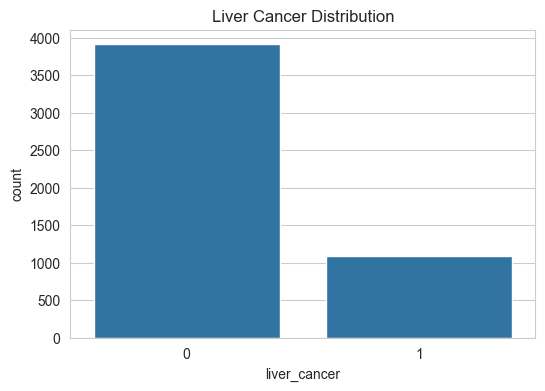

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='liver_cancer', data=df)
plt.title("Liver Cancer Distribution")
plt.show()

## Age Distribution

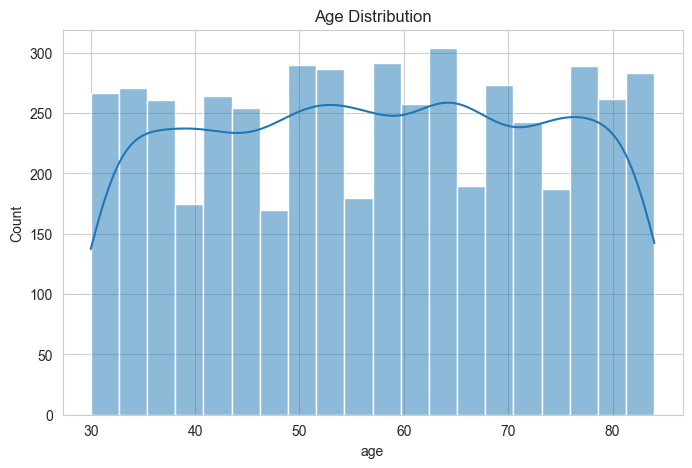

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

## BMI Distribution

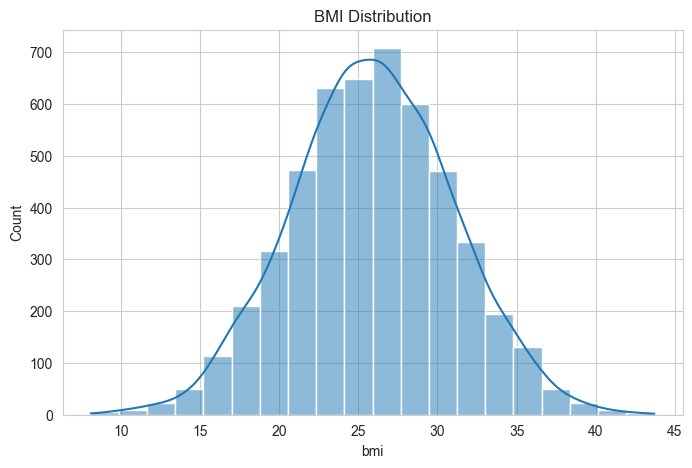

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

## Gender Distribution

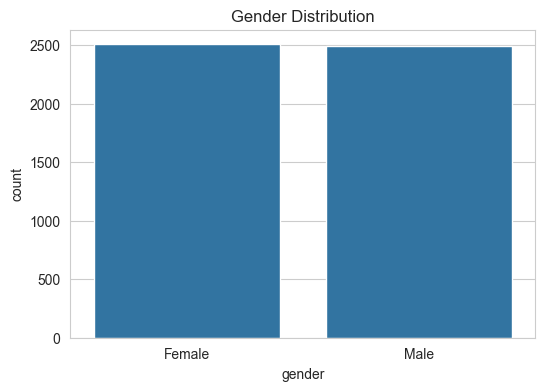

In [64]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Relationship Analysis of Columns / Features

## Age VS Liver Cancer

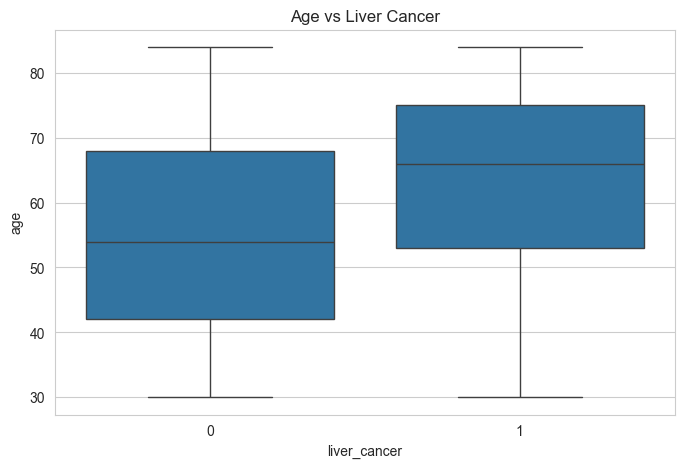

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(x='liver_cancer', y='age', data=df)
plt.title("Age vs Liver Cancer")
plt.show()

## BMI VS Liver Cancer

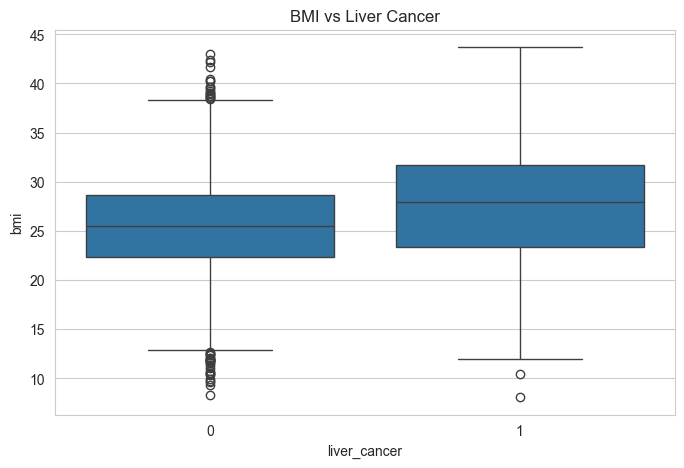

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(x='liver_cancer', y='bmi', data=df)
plt.title("BMI vs Liver Cancer")
plt.show()

## Alcohol VS Liver Cancer

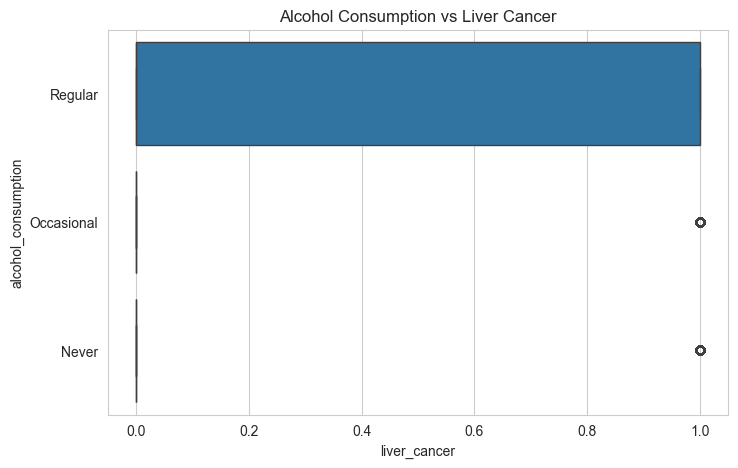

In [67]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='liver_cancer',
    y='alcohol_consumption',
    data=df
)
plt.title("Alcohol Consumption vs Liver Cancer")
plt.show()

## AFP VS Liver Cancer

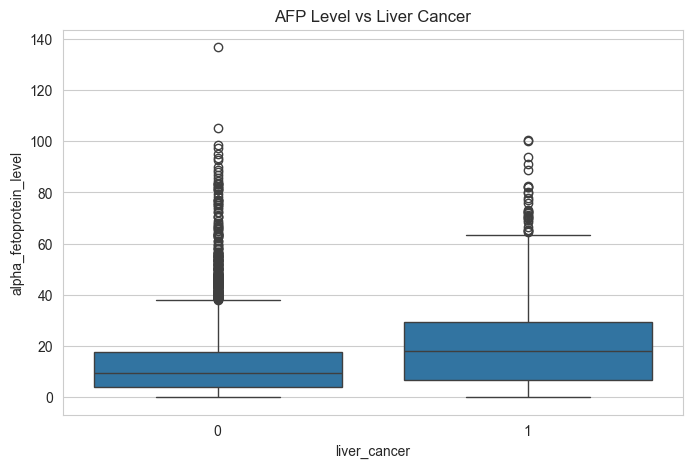

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='liver_cancer',
    y='alpha_fetoprotein_level',
    data=df
)
plt.title("AFP Level vs Liver Cancer")
plt.show()

## Cirrhosis History

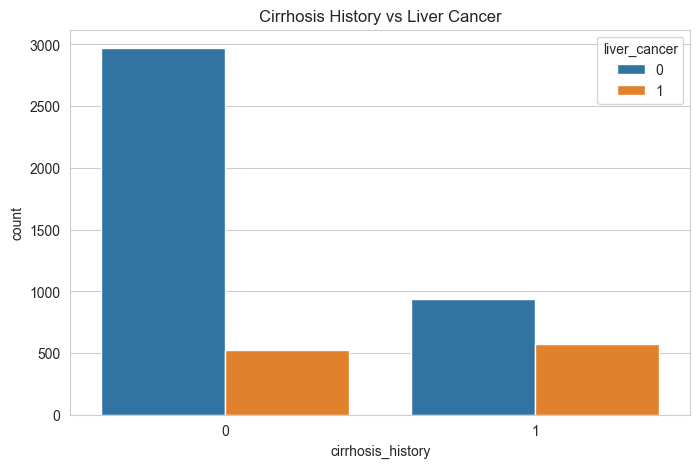

In [69]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='cirrhosis_history',
    hue='liver_cancer',
    data=df
)
plt.title("Cirrhosis History vs Liver Cancer")
plt.show()

## Hepatitis B

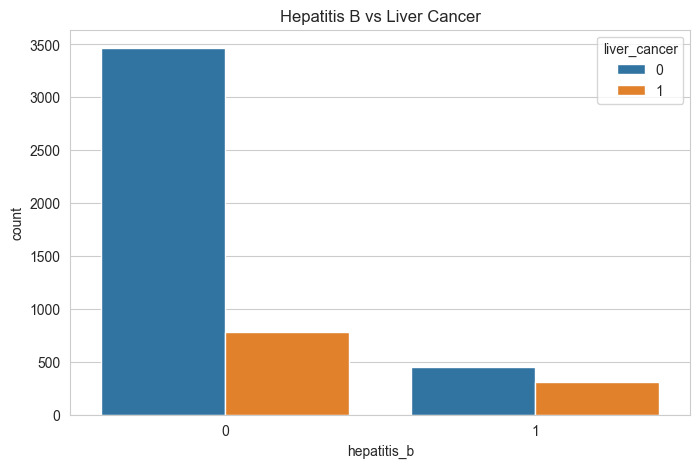

In [70]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='hepatitis_b',
    hue='liver_cancer',
    data=df
)
plt.title("Hepatitis B vs Liver Cancer")
plt.show()

## Hepatitis C

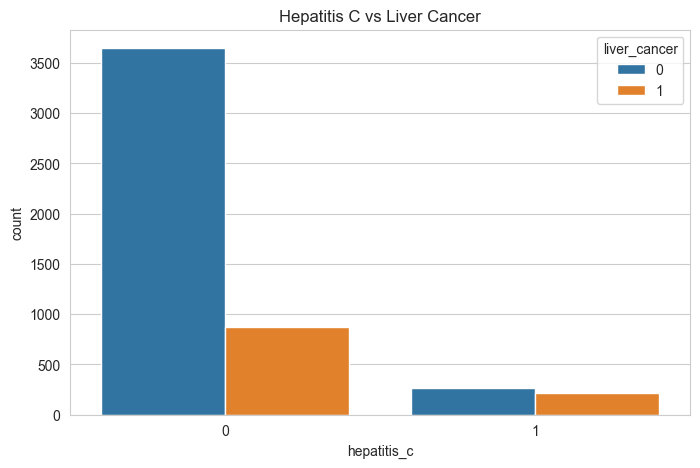

In [71]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='hepatitis_c',
    hue='liver_cancer',
    data=df
)
plt.title("Hepatitis C vs Liver Cancer")
plt.show()

## Encoding

In [72]:
le = LabelEncoder()
for col in df.columns:    
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

## CORRELATION HEATMAP

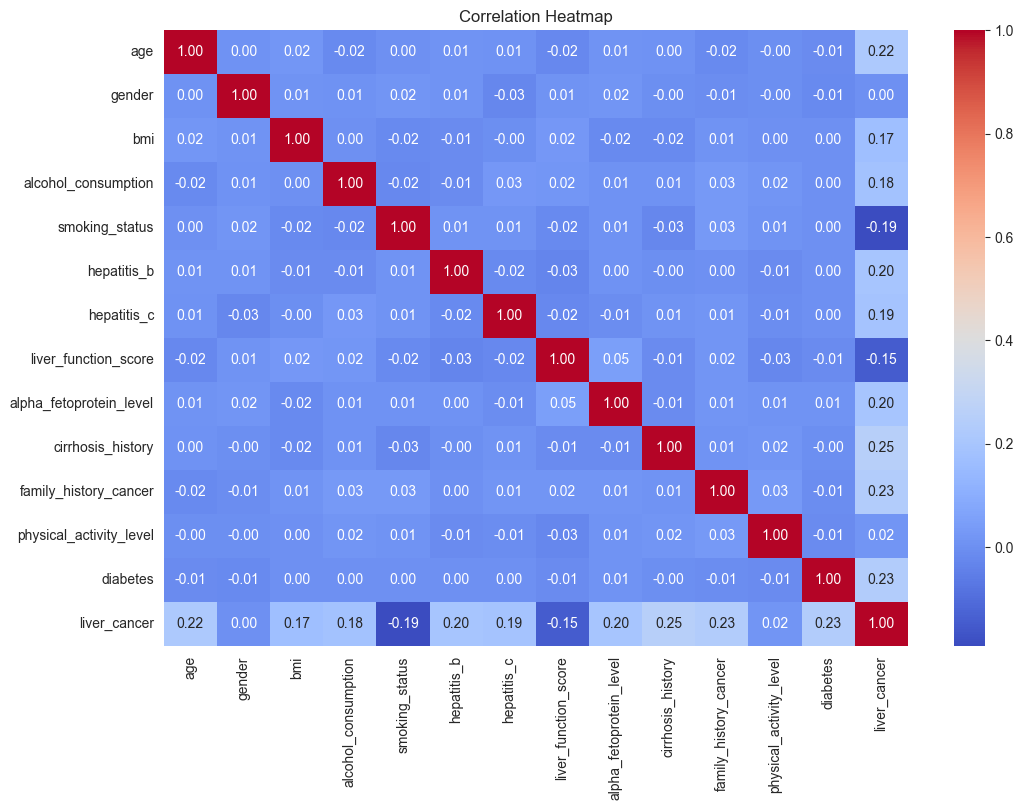

In [73]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# X and Y for model training

In [74]:
X = df.drop("liver_cancer", axis=1)
y = df["liver_cancer"]

## Model Training

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Model

In [76]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

## Training

In [77]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    results.append([name, accuracy])
    print("\n")
    print("="*50)
    print(name)
    print("="*50)
    print("Accuracy:", accuracy)
    print("\nClassification Report")
    print(classification_report(y_test, pred))



Logistic Regression
Accuracy: 0.905

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       782
           1       0.82      0.73      0.77       218

    accuracy                           0.91      1000
   macro avg       0.87      0.84      0.86      1000
weighted avg       0.90      0.91      0.90      1000



Decision Tree
Accuracy: 0.907

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       782
           1       0.78      0.80      0.79       218

    accuracy                           0.91      1000
   macro avg       0.86      0.87      0.86      1000
weighted avg       0.91      0.91      0.91      1000



Random Forest
Accuracy: 0.939

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       782
           1       0.95      0.76      0.84       218

    accurac

## MODEL COMPARISON

                 Model  Accuracy
0  Logistic Regression     0.905
1        Decision Tree     0.907
2        Random Forest     0.939


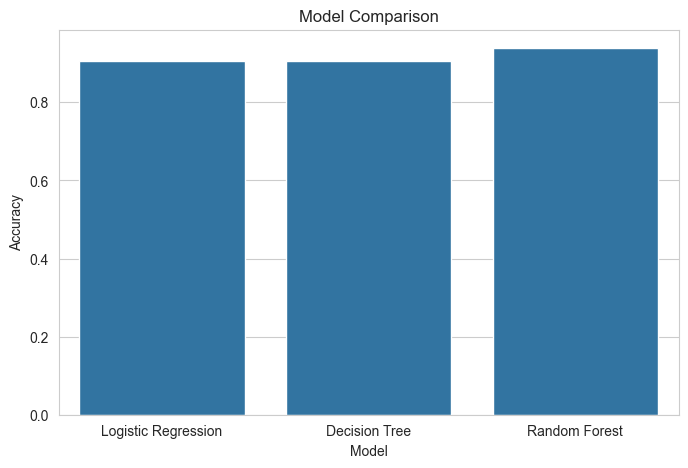

In [78]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

print(results_df)
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)
plt.title("Model Comparison")
plt.show()

## FEATURE IMPORTANCE

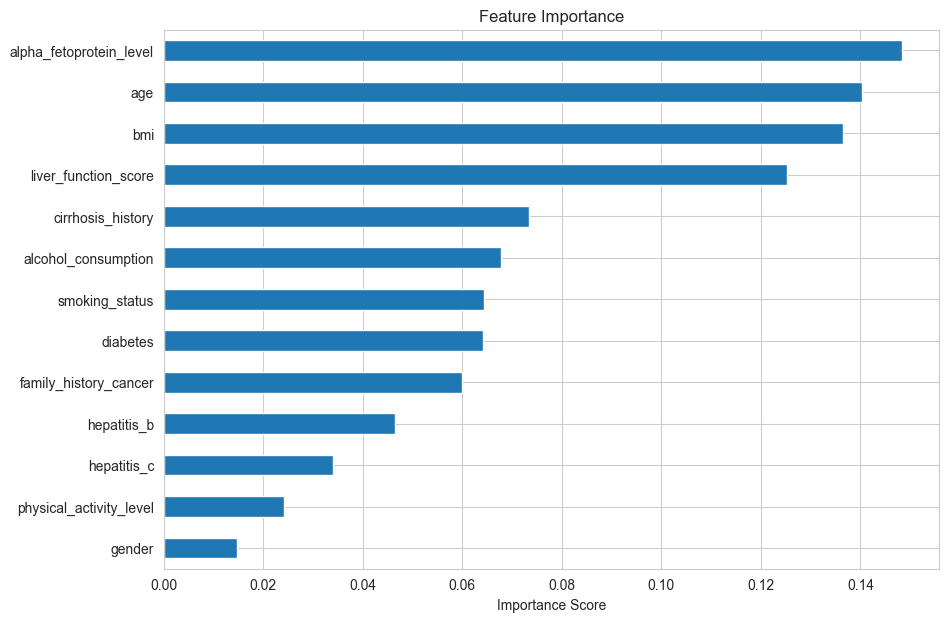

In [79]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()
plt.figure(figsize=(10,7))
importance.plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

## CONFUSION MATRIX

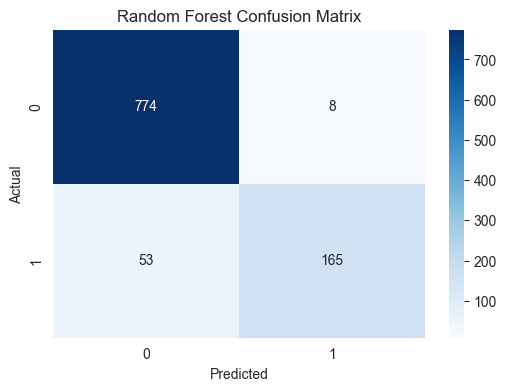

In [80]:
pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ROC Curve

In [ ]:
prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(
    y_test,
    prob
)

auc = roc_auc_score(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("\nProject Completed Successfully")